This file is for tryig for correcting the error that we analyze in previous file that 35 and 36 classes are the most confused

In [1]:
import pandas as pd
import regex as re
import torch

In [2]:
df = pd.read_csv(r'D:\Traffic\labels_processed.csv')

In [3]:
def label_function(dpath):
    class_name = re.findall(r'(\d+)_.*\.png$', dpath.name)
    class_id = int(class_name[0])
    return class_id

In [4]:
from pathlib import Path

In [5]:
path = Path(r'D:\Traffic\traffic_Data_processed\DATA')

In [6]:
lr_head = 0.0017378008365631102
lr_whole_model = 1.9054607491852948e-06

In [7]:
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [8]:
from torch.utils.data import Dataset
from PIL import Image

In [9]:
class dset(Dataset):
    def __init__(self, image_paths, transform = None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        label = label_function(Path(image_path))
        if self.transform:
            image = self.transform(image)
        return image, label

In [10]:
image_paths = list(path.rglob("*.png"))

In [11]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = dset(image_paths = image_paths, transform = transform)

In [12]:
from torch.utils.data import random_split

ts = int(0.75*len(dataset))
vs = len(dataset) - ts
generator = torch.Generator().manual_seed(42)
train_dataset, valid_dataset = random_split(dataset, [ts, vs], generator)

In [13]:
from torch.utils.data import DataLoader

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=16,
    shuffle=False
)

In [15]:
import torchvision
num_classes = 55
device = torch.device("cuda")

In [16]:
import kornia.augmentation as K
import torch.nn as nn

In [17]:
model_1 = torchvision.models.resnet34(weights="DEFAULT")
model_1.fc = nn.Linear(
    model_1.fc.in_features,
    num_classes
)

model_1 = model_1.to(device)

for param in model_1.parameters():
    param.requires_grad = False

for param in model_1.fc.parameters():
    param.requires_grad = True

train_aug_1 = K.AugmentationSequential(
    K.ColorJiggle(
        contrast = 0.2,
        p = 0.5
    ),
    K.RandomPlanckianJitter(
        mode = "CIED",
        p = 0.5
    )
).to(device)

targeted_aug_1 = K.AugmentationSequential(
    K.RandomRotation(
        degrees = 10,
        p = 0.5
    ),
    K.RandomAffine(
        degrees = 0,
        scale = (0.9, 1.1),
        p = 0.5
    ),
    K.RandomPerspective(
        distortion_scale = 0.2,
        p = 0.5
    ),
    K.ColorJiggle(
        brightness = 0.2,
        contrast = 0.2,
        p = 0.5
    )
).to(device)

optimizer_1 = torch.optim.RMSprop(
    model_1.fc.parameters(),
    lr=lr_head,
    weight_decay=1e-3
)

scheduler_1 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_1,
    max_lr = lr_head,
    epochs = 20,
    steps_per_epoch = len(train_loader)
)

criterion = nn.CrossEntropyLoss()

for epoch in range(20):
    model_1.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        images = train_aug_1(images)

        mask = (labels == 35) | (labels == 36)

        if mask.any():
            images[mask] = targeted_aug_1(images[mask])

        optimizer_1.zero_grad()

        outputs = model_1(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer_1.step()

        scheduler_1.step()

        train_loss += loss.item()

        _, predicted = outputs.max(1)

        train_correct += (predicted == labels).sum().item()

        train_total += labels.size(0)

    train_acc = 100 * train_correct / train_total

    model_1.eval()

    valid_loss = 0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_1(images)

            loss = criterion(outputs, labels)

            valid_loss += loss.item()

            _, predicted = outputs.max(1)

            valid_correct += (predicted == labels).sum().item()

            valid_total += labels.size(0)

    valid_acc = 100 * valid_correct / valid_total

    print(
        f"Epoch {epoch+1}/20 | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Valid Acc: {valid_acc:.2f}%"
    )

Epoch 1/20 | Train Acc: 63.57% | Valid Acc: 87.67%
Epoch 2/20 | Train Acc: 88.50% | Valid Acc: 87.19%
Epoch 3/20 | Train Acc: 87.70% | Valid Acc: 91.33%
Epoch 4/20 | Train Acc: 86.77% | Valid Acc: 88.63%
Epoch 5/20 | Train Acc: 88.53% | Valid Acc: 88.92%
Epoch 6/20 | Train Acc: 88.40% | Valid Acc: 93.55%
Epoch 7/20 | Train Acc: 89.17% | Valid Acc: 92.10%
Epoch 8/20 | Train Acc: 90.17% | Valid Acc: 89.98%
Epoch 9/20 | Train Acc: 90.14% | Valid Acc: 91.71%
Epoch 10/20 | Train Acc: 90.27% | Valid Acc: 93.26%
Epoch 11/20 | Train Acc: 91.55% | Valid Acc: 94.12%
Epoch 12/20 | Train Acc: 92.80% | Valid Acc: 95.28%
Epoch 13/20 | Train Acc: 92.77% | Valid Acc: 92.58%
Epoch 14/20 | Train Acc: 94.96% | Valid Acc: 94.80%
Epoch 15/20 | Train Acc: 94.31% | Valid Acc: 96.63%
Epoch 16/20 | Train Acc: 95.66% | Valid Acc: 96.72%
Epoch 17/20 | Train Acc: 97.98% | Valid Acc: 98.17%
Epoch 18/20 | Train Acc: 98.27% | Valid Acc: 98.17%
Epoch 19/20 | Train Acc: 99.20% | Valid Acc: 98.55%
Epoch 20/20 | Train A

In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

model_1.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in valid_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_1(images)

        _, predicted = outputs.max(1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

accuracy = accuracy_score(all_labels, all_predictions)

print(f"Accuracy: {accuracy * 100:.2f}%")

print(
    classification_report(
        all_labels,
        all_predictions,
        labels=list(range(num_classes)),
        zero_division=0
    )
)

cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=list(range(num_classes))
)

np.set_printoptions(threshold=np.inf)
print(cm)

Accuracy: 98.94%
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        35
           1       0.78      0.78      0.78         9
           2       0.90      1.00      0.95        18
           3       0.99      0.97      0.98        72
           4       1.00      1.00      1.00        30
           5       1.00      1.00      1.00        50
           6       1.00      1.00      1.00        13
           7       1.00      0.96      0.98        45
           8       1.00      1.00      1.00         1
           9       0.00      0.00      0.00         0
          10       1.00      1.00      1.00        15
          11       1.00      1.00      1.00        37
          12       1.00      1.00      1.00        25
          13       1.00      1.00      1.00         7
          14       1.00      1.00      1.00        36
          15       1.00      1.00      1.00         4
          16       1.00      1.00      1.00        38
          

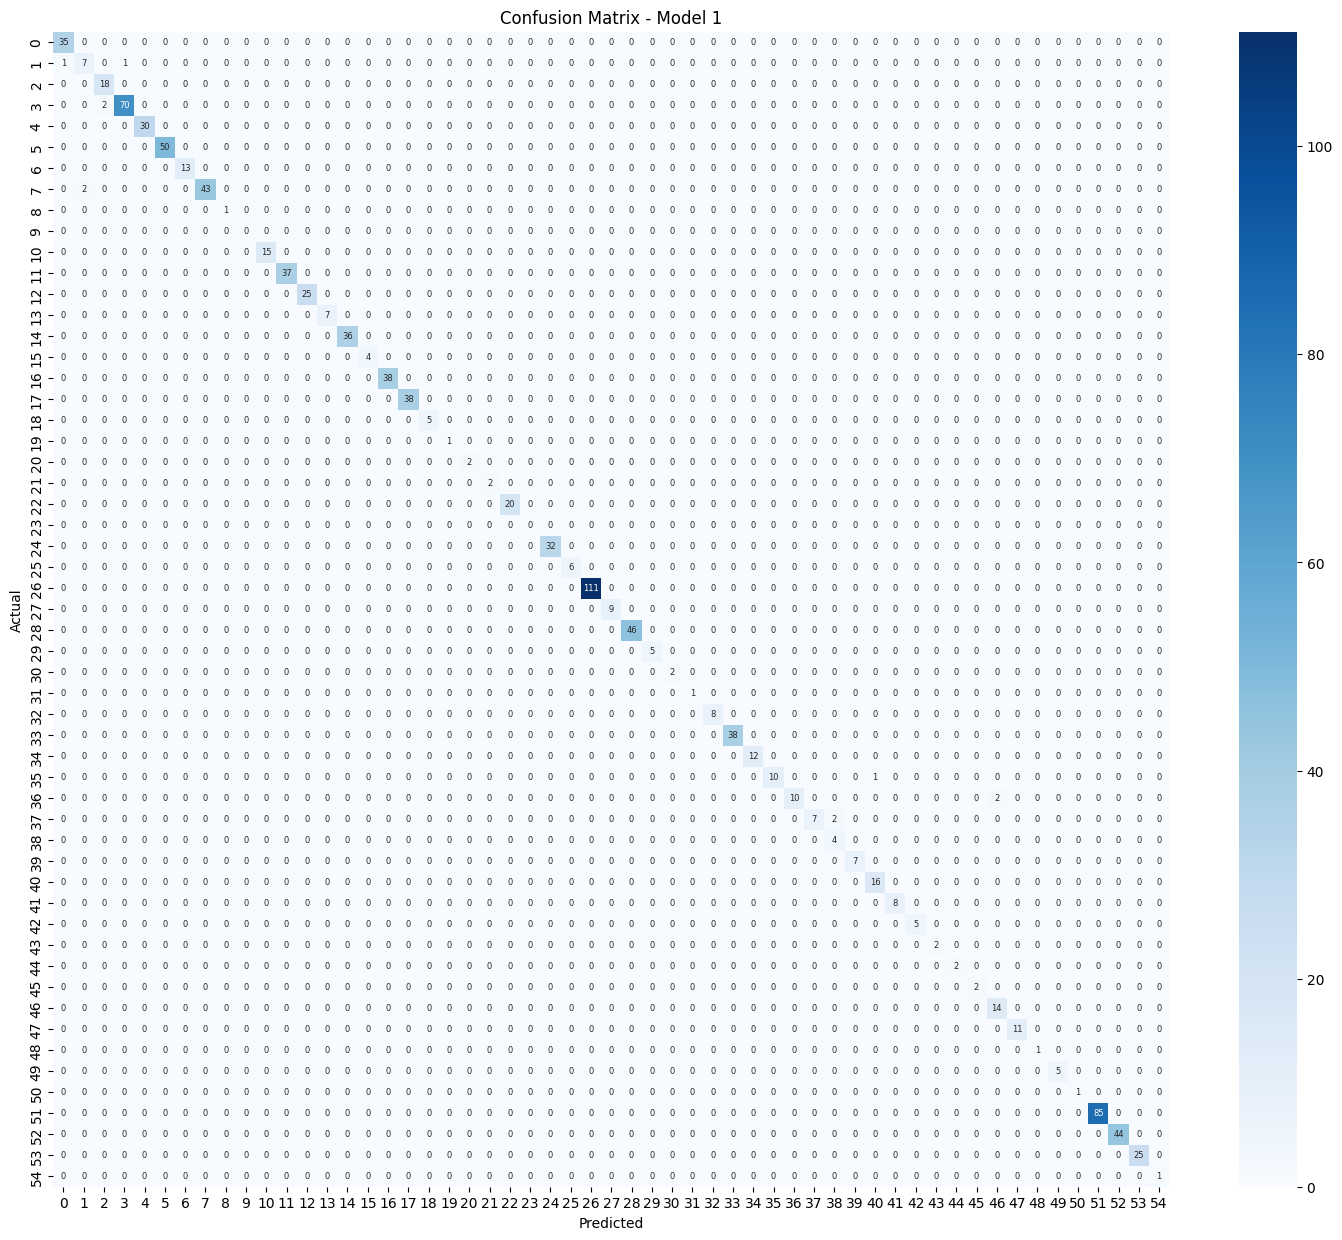

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 15))

sns.heatmap(
    cm,                      # your matrix from the evaluation cell
    annot=True,
    fmt="d",
    cmap="Blues",
    annot_kws={"size": 6}    # small font so numbers fit with many classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Model 1")

plt.savefig("confusion_matrix.png", dpi=200, bbox_inches="tight")  # before show()
plt.show()

In [22]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

model_1.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_1(images)
        _, predicted = outputs.max(1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

accuracy = accuracy_score(all_labels, all_predictions)
macro_f1 = f1_score(all_labels, all_predictions, average="macro")

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Macro F1: {macro_f1:.4f}")
print(classification_report(
    all_labels,
    all_predictions,
    labels=list(range(num_classes)),
    zero_division=0
))

Accuracy: 98.94%
Macro F1: 0.9831
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        35
           1       0.78      0.78      0.78         9
           2       0.90      1.00      0.95        18
           3       0.99      0.97      0.98        72
           4       1.00      1.00      1.00        30
           5       1.00      1.00      1.00        50
           6       1.00      1.00      1.00        13
           7       1.00      0.96      0.98        45
           8       1.00      1.00      1.00         1
           9       0.00      0.00      0.00         0
          10       1.00      1.00      1.00        15
          11       1.00      1.00      1.00        37
          12       1.00      1.00      1.00        25
          13       1.00      1.00      1.00         7
          14       1.00      1.00      1.00        36
          15       1.00      1.00      1.00         4
          16       1.00      1.00      1.00    

So the targeted correction worked 